In [1]:
%load_ext autoreload
%autoreload 2

from collections import OrderedDict
from qiskit_metal import designs
from qiskit_metal import MetalGUI, Dict
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander
from qiskit_metal.qlibrary.tlines.pathfinder import RoutePathfinder

from qiskit_metal.qlibrary.tlines.anchored_path import RouteAnchors

from qiskit_metal.qlibrary.terminations.launchpad_wb_driven import LaunchpadWirebondDriven #bonding
from qiskit_metal.qlibrary.terminations.short_to_ground import ShortToGround


from SQDMetal.Utilities.QUtilities import QUtilities
import matplotlib.pyplot as plt
import numpy as np
from qiskit_metal.toolbox_python.attr_dict import Dict

from toolkit.components.qubit.circle_transmon import CircTransmon

from scipy.constants import c, e, hbar
from scipy.constants import physical_constants as pc
# %matplotlib inline

In [2]:
res_len_lambda_2 = lambda eff, f: c/(2*np.sqrt(eff)*f)*1e3 # in mm
res_len_lambda_4 = lambda eff, f: c/(4*np.sqrt(eff)*f)*1e3 # in mm

In [3]:
# design = designs.DesignPlanar({}, overwrite_enabled=True)

design = designs.DesignPlanar()
design.chips.main.material = 'silicon'

design.variables['cpw_width'] = '20um' #S from reference 2
design.variables['cpw_gap'] = '11um' #W from reference 2
design._chips['main']['size']['size_x'] = '5mm'
design._chips['main']['size']['size_y'] = '5mm'
design._chips['main']['size']['size_z'] = '-600um' #Our wafer thicknes is 525 um+/-10
design.chips.main.size.center_x = '1.25mm'
design.chips.main.size.center_y = '2.5mm'

# If you disable the next line with "overwrite_enabled", then you will need to
# delete a component [<component>.delete()] before recreating it.
design.overwrite_enabled = True

In [4]:
# gui = MetalGUI(design)

In [5]:
options = Dict(
        # Position and orientation
        pos_x='1.8mm', pos_y='1.6mm', orientation=0, chip='main',
        cpw_width=design.variables['cpw_width'], cpw_gap=design.variables['cpw_gap'],

        # Pads (capacitor)
        pad_radius = '120um',
        pad_gap = '10um',

        # jj (mesoscopic: 0 or small junction: 1)
        jj_options=Dict(
            jj_width='5um',
            L_j = '40.7885nH',
            C_j = '0.72fF',
            export_mask = False,    # if True, draw a rectangle where the constriction will be made. If false, we keep a gap of jj_sim_gap in which we insert a jj element to make the simulation
            gds_cell_jj = 'gds_cell_jj',
            jj_sim_gap = '8um', # if we need a small junction, we can increase this gap
            ),
        
        # Coupled claws (2 claws allowed   )
        claw_a_options= Dict(
            make_claw=True,
            connector_location='90',  # 0 => 'west' arm, 90 => 'north' arm, 180 => 'east' arm
            claw_width='50um',
            claw_gap='30um',
            claw_length='200um',
            ground_spacing='10um',
            connector_length='70um',
            ),
        claw_b_options=Dict(
            make_claw=False,
            connector_location='0',  # 0 => 'west' arm, 90 => 'north' arm, 180 => 'east' arm
            claw_width='50um',
            claw_gap='30um',
            claw_length='100um',
            ground_spacing='10um',
            connector_length='50um',
            ),

        # Charge line
        charge_line=Dict(
            make_charge_line=True,
            location = '180', # 0 => 'west' arm, 90 => 'north' arm, 180 => 'east' arm. Must be different from claw_a and claw_b if they exist
            pad_radius='40um',
            pad_gap='40um', # gap between the pad and qubit
            ground_spacing='15um', # distance from the charge line to the ground
            line_length='100um',
            )
        )

# Create a fluxonium qubit with the Manucharyan design
qubit_1 = CircTransmon(design, 'Q1', options=options)


# gui.rebuild()
# gui.autoscale()

In [6]:
x1 = '0.25mm'
y1 = '3.2mm'

ops_1 = Dict(chip='main', pos_x=x1, pos_y=y1, orientation='360', lead_length='10um', 
             pad_width='120um', pad_gap='61um', trace_width=design.variables['cpw_width'] , trace_gap=design.variables['cpw_gap'] )
LP1 = LaunchpadWirebondDriven(design, 'LP1', options = ops_1)

# Driven Launchpad 2

x2 = '3mm'
y2 = '3.2mm'
ops_2 = Dict(chip='main', pos_x=x2, pos_y=y2, orientation='180', lead_length='10um',
             pad_width='120um', pad_gap='61um', trace_width=design.variables['cpw_width'] , trace_gap=design.variables['cpw_gap'] )
LP2 = LaunchpadWirebondDriven(design, 'LP2', options = ops_2)


# Rebuild the GUI 
# gui.rebuild()
# gui.autoscale()

## Conecto LP1 con el extremo izquierdo del capacitor
opt_line = Dict(chip='main', trace_width =design.variables['cpw_width'] ,
        trace_gap =design.variables['cpw_gap'] , fillet='0um', hfss_wire_bonds = True, lead=Dict(end_straight='0.0mm'),
        pin_inputs=Dict(start_pin=Dict(component='LP1', pin='tie'),
                        end_pin=Dict(component='LP2', pin='tie')
                        )
               )

linea_1 = RoutePathfinder(design, 'linea_1', options = opt_line )

# Rebuild the GUI
# gui.rebuild()
# gui.autoscale() 


In [7]:
# charge lumped port
ops_charge_line = Dict(chip='main', pos_x='0.5mm', pos_y='1.6mm', orientation='0', lead_length='10um',
             pad_width='120um', pad_gap='61um', trace_width=design.variables['cpw_width'] , trace_gap=design.variables['cpw_gap'] )

LPC = LaunchpadWirebondDriven(design, 'LPC', options = ops_charge_line)

# Rebuild the GUI
# gui.rebuild()
# gui.autoscale()


In [8]:
# Connect LPC with charge_line pad
# anchors_points = [(0.7, 2), (0.7, 2.5), (0.8, 2.5), (1, 1.6)]
# anchors_dict = OrderedDict({i: point for i, point in enumerate(anchors_points)})

opt_line_charge = Dict(chip='main', trace_width =design.variables['cpw_width'],
        trace_gap = design.variables['cpw_gap'], hfss_wire_bonds = True, lead=Dict(end_straight='0.0mm'),
        pin_inputs=Dict(start_pin=Dict(component='LPC', pin='tie'),
                        end_pin=Dict(component='Q1', pin='charge_line')
                        )
                )

con_charge_line = RoutePathfinder(design, 'con_charge_line', options = opt_line_charge )
# gui.rebuild()
# gui.autoscale()

In [9]:
## Estimation for the resonator length
eff=(11.9+1)/2 ## Si and Air
f=7e9  # Resonator frequency in Hz

stg1 = ShortToGround(design, 'stg1', options=Dict(chip='main', pos_x='1mm',  pos_y='2.3mm', orientation='180'))

In [10]:
jogs = OrderedDict()
jogs[0] = ["L", '400um']
jogs[1] = ["L", '100um']
# jogs[1] = ["L", '300um']
# jogs[2] = ["R", '200um']
l = res_len_lambda_4(eff, f)  # in mm
total_length = f'{l}mm'

opt_meander = Dict(
    trace_width= design.variables['cpw_width'] ,
    trace_gap= design.variables['cpw_gap'] ,
    hfss_wire_bonds= True,
    meander=Dict(
        spacing= '250um',
        asymmetry= '0um'),    
    total_length= total_length,
    fillet = '90um',
    pin_inputs=Dict(
        end_pin=Dict(
            component= 'Q1',
            pin= 'claw_a'),
        start_pin=Dict(
            component= 'stg1',
            pin= 'short')),
    lead=Dict(
        start_straight='0.02mm',
        end_straight='1.278mm',
        end_jogged_extension=jogs
        ),
)
meandro_1 = RouteMeander(design, 'meandro_1',  options=opt_meander)

# # rebuild the GUI
# gui.rebuild()
# gui.autoscale()

In [11]:
# Ajustar el chip al bounding box real del circuito antes de exportar a PALACE.
all_components = list(design.components.keys())
min_x, min_y, max_x, max_y = QUtilities.get_comp_bounds(design, all_components, units_metres=True)

chip_margin = 0.15e-3  # 150 um de margen alrededor del diseño
chip_size_x = (max_x - min_x) + 2 * chip_margin
chip_size_y = (max_y - min_y) + 2 * chip_margin
chip_center_x = 0.5 * (min_x + max_x)
chip_center_y = 0.5 * (min_y + max_y)

design.chips.main.size.size_x = f'{chip_size_x * 1e3:.4f}mm'
design.chips.main.size.size_y = f'{chip_size_y * 1e3:.4f}mm'
design.chips.main.size.center_x = f'{chip_center_x * 1e3:.4f}mm'
design.chips.main.size.center_y = f'{chip_center_y * 1e3:.4f}mm'

# gui.rebuild()
# gui.autoscale()

Simulations

Write text here

In [12]:
from toolkit.tools.sim.sim_subdesign import build_subdesign

# keep = solo lo que rodea a Q1 (LP1/LP2/linea_1 de feedline + stg1/meandro_1 del resonador).
# meandro_1.end_pin apuntaba a Q1.claw_a; como Q1 no esta en keep, ese extremo queda colgando
# y se termina en open (misma logica que el open_pins de Ansys/HFSS).
design_sub = build_subdesign(
    design,
    keep=['meandro_1', 'stg1', 'LP1', 'LP2', 'linea_1'],
    terminations={('meandro_1', 'end'): 'open'},
)

Sub-design created. Components kept (5): ['LP1', 'LP2', 'linea_1', 'meandro_1', 'stg1']
Terminations added for dangling pins:
  - term_meandro_1_end (open) replacing Q1.claw_a


In [13]:
gui2 = MetalGUI(design_sub)

In [14]:
from SQDMetal.PALACE.Frequency_Driven_Simulation import PALACE_Driven_Simulation
from SQDMetal.Utilities.Materials import MaterialInterface
import multiprocessing as mp

# number_cpus = mp.cpu_count()
number_cpus = 4
path2palace = "/Users/maximilianogatto/Library/CloudStorage/OneDrive-Personal/PhD/src/libraries/palace/build/bin/palace"

#Driven (S-parameter) Simulation Options
user_defined_options = {
                "mesh_refinement":  0,                             #refines mesh in PALACE - essetially divides every mesh element in half
                "dielectric_material": "silicon",                  #choose dielectric material - 'silicon' or 'sapphire'
                "solns_to_save": 4,                                #number of frequency points to save full field solutions for
                "solver_order": 1,                                 #increasing solver order increases accuracy of simulation, but significantly increases sim time
                "solver_tol": 1.0e-3,                              #error residual tolerance for iterative solver
                "solver_maxits": 300,                              #number of solver iterations
                "fillet_resolution":12,                            #number of vertices per quarter turn on a filleted path
                "palace_dir": path2palace,                         #"PATH/TO/PALACE/BINARY",
                "num_cpus": number_cpus                             #number of cpus used in simulation
                }

#Create the Palace Driven (S-parameter) simulation
driven_sim = PALACE_Driven_Simulation(name ='circTransmon_S21',                                    #name of simulation
                                        metal_design = design_sub,                                      #feed in qiskit metal design
                                        sim_parent_directory = "",                                  #choose directory where mesh file and config file are saved
                                        mode = 'simPC',                                             #choose simulation mode 'HPC' or 'simPC'
                                        meshing = 'GMSH',                                           #choose meshing 'GMSH' or 'COMSOL'
                                        user_options = user_defined_options,                        #provide options chosen above
                                        create_files = True)                                        #create mesh, config and HPC batch files

#Add in metals from layer 1 of the design file
driven_sim.add_metallic(1)

#Add in ground plane for simulation
driven_sim.add_ground_plane()

# driven_sim.create_port_CPW_on_Launcher('LP1', len_launch=20e-6, impedance_R=50)
# driven_sim.create_port_CPW_on_Launcher('LP2', len_launch=20e-6, impedance_R=50)

# Fine mesh moderado siguiendo el centro de las rutas CPW largas.
driven_sim.fine_mesh_along_path(
    qObjName='meandro_1',
    dist_resolution=10e-6,
    min_size=6e-6, 
    max_size=150e-6, 
    taper_dist_min=10e-6
)

driven_sim.fine_mesh_components(
    ['LP1', 'LP2'],
    min_size=8e-6,
    max_size=100e-6,
    taper_dist_min=10e-6,
    metals_only=False
)

# driven_sim.enable_mesh_refinement
# Barrido en frecuencia: la firma real es (freq_start, freq_end, freq_step) en Hz -- NO
# (freq_start, freq_stop, freq_points) como estaba antes.
freq_points = 101
freq_start = 6.5e9
freq_end = 7.5e9
freq_step = (freq_end - freq_start) / (freq_points - 1)

driven_sim.set_freq_values(
    freq_start=freq_start,
    freq_end=freq_end,
    freq_step=freq_step
)

# Excita el puerto 1 (LP1, por el orden de creacion de arriba). Para excitar por LP2 en
# vez de LP1, usar port_index=2. Si no se llama, SQDMetal toma automaticamente el primer
# puerto resistivo (R>0) como excitacion -> en este caso tambien seria LP1.
# driven_sim.set_port_excitation(port_index=1)

#Prepares the mesh file and config file
driven_sim.prepare_simulation()

In [15]:
import json
with open(driven_sim._sim_config) as f:
    cfg = json.load(f)
cfg['Solver']['Driven']['AdaptiveTol'] = 1e-3   # tolerancia relativa del PROM
with open(driven_sim._sim_config, 'w') as f:
    json.dump(cfg, f, indent=2)

In [16]:
driven_sim.open_mesh_gmsh()

In [ ]:
run = True
if run:
    res = driven_sim.run(stream_output=True)

>> /opt/homebrew/bin/mpirun -n 4 /Users/maximilianogatto/Library/CloudStorage/OneDrive-Personal/PhD/src/libraries/palace/build/bin/palace-arm64.bin circTransmon_S21.json

_____________     _______
_____   __   \____ __   /____ ____________
____   /_/  /  __ ` /  /  __ ` /  ___/  _ \
___   _____/  /_/  /  /  /_/  /  /__/  ___/
  /__/     \___,__/__/\___,__/\_____\_____/


--> Warning!
Output folder is not empty; program will overwrite content! (outputFiles)

---------- Registering Backends ----------

Weak Register   : /cpu/self/avx/blocked
Weak Register   : /cpu/self/avx/serial
Weak Register   : /gpu/cuda/ref
Weak Register   : /gpu/cuda/gen
Weak Register   : /gpu/cuda/shared
Weak Register   : /gpu/hip/ref
Weak Register   : /gpu/hip/gen

---------- Registering Backends ----------

Weak Register   : /cpu/self/avx/blocked
Weak Register   : /cpu/self/avx/serial
Weak Register   : /gpu/cuda/ref
Weak Register   : /gpu/cuda/gen
Weak Register   : /gpu/cuda/shared
Weak Register   : /gpu/hip/ref


KeyboardInterrupt: 

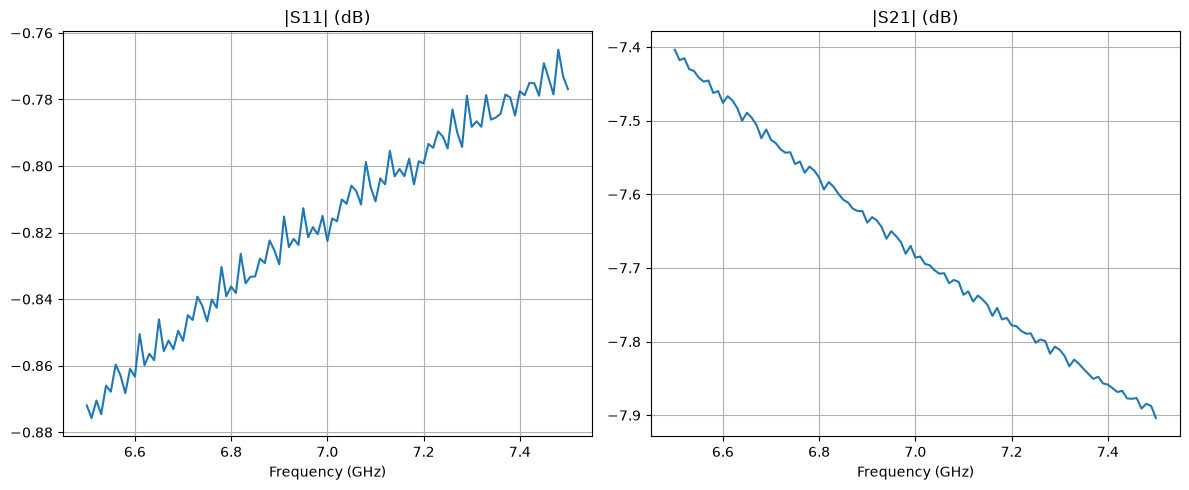

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

freqs_GHz = res['freqs'] / 1e9

fig, axs = plt.subplots(ncols=2, figsize=(12, 5))
axs[0].plot(freqs_GHz, 20*np.log10(np.abs(res['S11'])))
axs[0].set_title('|S11| (dB)')
axs[0].set_xlabel('Frequency (GHz)')
axs[0].grid()

axs[1].plot(freqs_GHz, 20*np.log10(np.abs(res['S21'])))
axs[1].set_title('|S21| (dB)')
axs[1].set_xlabel('Frequency (GHz)')
axs[1].grid()

fig.tight_layout()

In [ ]:
idx_dip = np.argmin(np.abs(res['S21']))
print(f"Minimo de |S21| en {res['freqs'][idx_dip]/1e9:.4f} GHz -> {20*np.log10(np.abs(res['S21'][idx_dip])):.2f} dB")

Minimo de |S21| en 7.5000 GHz -> -7.90 dB
